Cài đặt thư viện và cấu hình

In [1]:
import os
import shutil
import random
import kagglehub
import joblib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

EPOCHS = 40
BATCH_SIZE = 32
IMG_SIZE = (150, 150)
BASE_DIR = '/content/my_dataset'

#PHẦN 1: CHUẨN BỊ VÀ CÂN BẰNG DỮ LIỆU
Tải dataset gốc từ Kaggle. Dữ liệu thực tế thường bị mất cân bằng. Thuật toán dưới đây sẽ tự động tìm thư mục ảnh, lọc các file lỗi và chia đều số lượng ảnh cho mỗi lớp theo chuẩn: **400 Train - 100 Valid - 100 Test**

In [3]:

path = kagglehub.dataset_download("utkarshsaxenadn/fast-food-classification-dataset")

# Tìm mục chứa ảnh
true_train_path = ""
for root, dirs, files in os.walk(path):
    if "Train" in dirs and len(os.listdir(os.path.join(root, "Train"))) > 0:
        true_train_path = os.path.join(root, "Train")
        break

# Dọn mấy file cũ đã chạy
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

classes = sorted([d for d in os.listdir(true_train_path) if os.path.isdir(os.path.join(true_train_path, d))])[:10]
# Phân chia ảnh
for cls in classes:
    for split in ['Train', 'Valid', 'Test']:
        os.makedirs(os.path.join(BASE_DIR, split, cls), exist_ok=True)

    src = os.path.join(true_train_path, cls)
    imgs = [f for f in os.listdir(src) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.seed(42)
    random.shuffle(imgs)
    for i, f in enumerate(imgs[:600]):
        if i < 400: dest = 'Train'
        elif i < 500: dest = 'Valid'
        else: dest = 'Test'
        shutil.copy(os.path.join(src, f), os.path.join(BASE_DIR, dest, cls, f))

# Nạp vào tf.data
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'Train'), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'Valid'), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

Using Colab cache for faster access to the 'fast-food-classification-dataset' dataset.
Found 4000 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.


#PHẦN 2: MÔ HÌNH CƠ BẢN- BASELINE CNN - PHASE 1
Xây dựng mạng CNN thuần túy, độ sâu vừa phải, KHÔNG có tính năng Tăng cường dữ liệu. Mô hình này đóng vai trò làm điểm chuẩn để chứng minh tính hiệu quả của Phase 2.

Epoch 1/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.1395 - loss: 2.2727 - val_accuracy: 0.1720 - val_loss: 2.2635
Epoch 2/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.1863 - loss: 2.2108 - val_accuracy: 0.2140 - val_loss: 2.1918
Epoch 3/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.2165 - loss: 2.1564 - val_accuracy: 0.2270 - val_loss: 2.1336
Epoch 4/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.2438 - loss: 2.1049 - val_accuracy: 0.2170 - val_loss: 2.1356
Epoch 5/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.2582 - loss: 2.0657 - val_accuracy: 0.2370 - val_loss: 2.1025
Epoch 6/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.2887 - loss: 2.0218 - val_accuracy: 0.2850 - val_loss: 2.0454
Epoch 7/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.2977 - loss: 1.9964 - val_accuracy: 0.2640 - val_loss: 2.0935
Epoch 8/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.3140 - loss: 1.9686 - val_acc

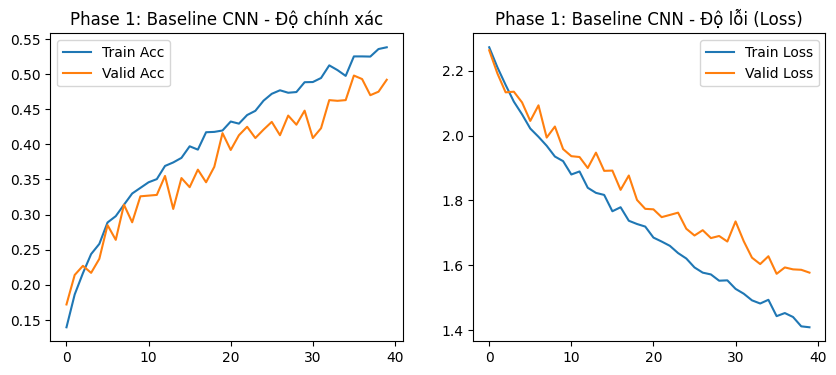

In [4]:
def build_baseline():
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),

        layers.GlobalAveragePooling2D(name="feature_layer"),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


model_p1 = build_baseline()
history_p1 = model_p1.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# File kết quả train
model_p1.save('baseline_model_p1.keras')

# Hàm vẽ biểu đồ
def plot_history(history, title):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Valid Acc')
    plt.title(f'{title} - Độ chính xác')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Valid Loss')
    plt.title(f'{title} - Độ lỗi (Loss)')
    plt.legend()
    plt.show()

plot_history(history_p1, "Phase 1: Baseline CNN")

#PHẦN 3: PHÂN CỤM DỮ LIỆU ĐỂ PHÂN TÍCH - CLUSTERING
Sử dụng mô hình Phase 1 để trích xuất đặc trưng hình ảnh, sau đó dùng thuật toán K-Means gom cụm thành 10 nhóm. Kỹ thuật này hỗ trợ tìm ra các bức ảnh gây nhiễu.

In [5]:

feature_extractor = models.Sequential(model_p1.layers[:-1])

image_batches = []
for imgs, labs in train_ds.take(20):
    image_batches.append(imgs)
images_only = np.concatenate(image_batches, axis=0)

# Dự đoán
features = feature_extractor.predict(images_only, verbose=0)
features_cos = normalize(features)

kmeans = KMeans(n_clusters=10, random_state=42).fit(features_cos)

# Xuất file K-Means
joblib.dump(kmeans, 'kmeans_model.pkl')

['kmeans_model.pkl']

#PHẦN 4: MODULE TĂNG CƯỜNG DỮ LIỆU & PHASE 2
Định nghĩa Module Augmentation hoạt động theo cơ chế **"On-the-fly"**. Module này được ghép vào một mạng Deep CNN sâu hơn, tích hợp Dropout để tránh tình trạng Học vẹt.

Epoch 1/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.1165 - loss: 2.2962 - val_accuracy: 0.1640 - val_loss: 2.2770
Epoch 2/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.1503 - loss: 2.2651 - val_accuracy: 0.1560 - val_loss: 2.2504
Epoch 3/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.1577 - loss: 2.2386 - val_accuracy: 0.1740 - val_loss: 2.2317
Epoch 4/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.1832 - loss: 2.2123 - val_accuracy: 0.1850 - val_loss: 2.1874
Epoch 5/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.2107 - loss: 2.1430 - val_accuracy: 0.2320 - val_loss: 2.1159
Epoch 6/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.2342 - loss: 2.1251 - val_accuracy: 0.2180 - val_loss: 2.1189
Epoch 7/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.2562 - loss: 2.0658 - val_accuracy: 0.2650 - val_loss: 2.0226
Epoch 8/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.2718 - loss: 2.0315 - val_acc

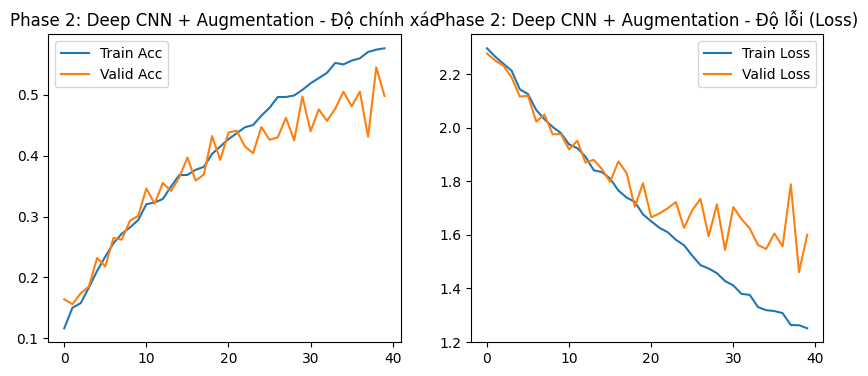

In [6]:
# 1. MODULE TĂNG CƯỜNG (DÙNG CHUNG)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="module_tang_cuong")

# 2. XÂY DỰNG DEEP CNN
model_p2 = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_p2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_p2 = model_p2.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# Xuất file train
model_p2.save('augmented_model_p2.keras')

plot_history(history_p2, "Phase 2: Deep CNN + Augmentation")